# Compare different models
This notebook aims to evaluate performance of multiple models across different datasets

In [1]:
import os
import numpy as np
import time
import sys

import pandas as pd
from tqdm import tqdm
from datetime import datetime
from dataclasses import dataclass
from typing import Literal, Annotated

sys.path.append("utils")
sys.path.append("src")

from src.models import BasePrecipitationModel

DATASET_PATH = "data/numpy_grid/"
RESULT_PATH = "output/results_with_std/"


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



/Users/trantrunghcmut/Documents/hcmut/Undergraduation Thesis - Thunderstorm Nowcasting/Thunderstorm-Nowcasting-Geometry-Approach/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup evaluation functions

In [2]:
from utils.evaluation_models import ModelSetting
from utils.dataframe_saving import check_override_result, save_results

@dataclass
class SensitivityAnalysisWithStdResults:
    pod_3: float
    far_3: float
    csi_3: float
    pod_3_std: float
    far_3_std: float
    csi_3_std: float
    pod_5: float
    far_5: float
    csi_5: float
    pod_5_std: float
    far_5_std: float
    csi_5_std: float
    object_consistency: float
    mean_duration: float
    linear_rmse: float
    optimal_tracking: float

    def print_result(self):
        print(f"Leading 6 time frames evaluation: POD@5: {self.pod_5:.4f}, FAR@5: {self.far_5:.4f}, CSI@5: {self.csi_5:.4f}")
        print(f"Leading 4 time frames evaluation: POD@3: {self.pod_3:.4f}, FAR@3: {self.far_3:.4f}, CSI@3: {self.csi_3:.4f}")
        print(f"Object consistency score: {self.object_consistency:.4f}")
        print(f"Mean duration of the tracks: {self.mean_duration:.4f} (minutes)")
        print(f"Linear RMSE: {self.linear_rmse:.4f} (km)")
        print(f"Optimal tracking evaluation score: {self.optimal_tracking:.4f}")

def check_override_result(dataset: str, analysis: ModelSetting, result_path: str) -> pd.DataFrame:
    """
        Implement logic to check if results already exist for the given dataset and analysis parameters
    """
    saved_path = os.path.join(result_path, f"{dataset}_models_evaluation.csv")
    if os.path.exists(saved_path):
        df = pd.read_csv(saved_path)
    else:
        df = pd.DataFrame(columns=["model_name", "maximum_velocity", "pod_3", "far_3", "csi_3", "pod_3_std", "far_3_std", "csi_3_std",
                            "pod_5", "far_5", "csi_5", "pod_5_std", "far_5_std", "csi_5_std",
                            "object_consistency", "mean_duration", "linear_rmse", "optimal_tracking"])
    
    # Check if the specific analysis parameters already exist in the dataframe
    existing = df[
        (df["model_name"] == analysis.model_name) &
        (df["maximum_velocity"] == analysis.max_velocity)
    ]

    return existing


def save_results(dataset: str, analysis: ModelSetting, results: SensitivityAnalysisWithStdResults, result_path: str):
    # Implement logic to save the results to disk
    saved_path = os.path.join(result_path, f"{dataset}_models_evaluation.csv")
    if os.path.exists(saved_path):
        df = pd.read_csv(saved_path)
    else:
        df = pd.DataFrame(columns=["model_name", "maximum_velocity", "pod_3", "far_3", "csi_3", "pod_3_std", "far_3_std", "csi_3_std",
                                   "pod_5", "far_5", "csi_5", "pod_5_std", "far_5_std", "csi_5_std",
                                   "object_consistency", "mean_duration", "linear_rmse", "optimal_tracking"])

    new_df = pd.Series({
        "model_name": analysis.model_name,
        "maximum_velocity": analysis.max_velocity,
        "pod_3": results.pod_3,
        "far_3": results.far_3,
        "csi_3": results.csi_3,
        "pod_3_std": results.pod_3_std,
        "far_3_std": results.far_3_std,
        "csi_3_std": results.csi_3_std,
        "pod_5": results.pod_5,
        "far_5": results.far_5,
        "csi_5": results.csi_5,
        "pod_5_std": results.pod_5_std,
        "far_5_std": results.far_5_std,
        "csi_5_std": results.csi_5_std,
        "object_consistency": results.object_consistency,
        "mean_duration": results.mean_duration,
        "linear_rmse": results.linear_rmse,
        "optimal_tracking": results.optimal_tracking
    })

    # Override the existing rows if they exist
    existing = check_override_result(dataset, analysis, result_path)
    if existing is not None and not existing.empty:
        exiting_idx = existing.index[0]
        df.loc[exiting_idx] = new_df
    else:
        df.loc[len(df)] = new_df

    df.sort_values(by=["model_name", "maximum_velocity"], inplace=True)
        
    df.to_csv(saved_path, index=False)

In [3]:
import cv2
from utils.data_loader import load_data

DATASOURCE = "numpy_grid"

def run_models_evaluation(dataset: str, analysis: ModelSetting, data_source: str = DATASOURCE) -> SensitivityAnalysisWithStdResults:
    """
        Main entries to run sensitivity analysis. Phases include:
            1. Load dataset and configure model with given parameters
            2. Identify storms in each frame
            3. Perform and evaluate nowcasting across time
            4. Evaluation of tracking performance
    """
    # Phase 1: Load dataset and configure model
    dbz_maps = load_data(dataset, data_source)

    print(f"Loaded {len(dbz_maps)} frames of data for dataset {dataset}.")

    # Phase 2: Identify storms
    storms_maps = []
    for idx, (dbz_map, time_frame) in tqdm(list(enumerate(dbz_maps)), desc="Identifying storms in each frame"):
        storms_map = analysis.model.identify_storms(dbz_map, time_frame, map_id=f"time_{idx}", threshold=35, filter_area=50)
        storms_maps.append(storms_map)

    # Phase 3: Evaluate Nowcasting across time
    from src.cores.metrics import PredictionBenchmarkModel

    # Evaluate for 3-step ahead prediction
    ours_model_evaluation_3 = PredictionBenchmarkModel()
    temp_storm_map = storms_maps

    model = analysis.model.copy()
    SLOW_START_STEPS = 3
    PREDICT_FORWARD_STEPS = 3

    for i in range(SLOW_START_STEPS):
        model.processing_map(temp_storm_map[i])  # Warm-up phase

    for curr_map, future_map in tqdm(list(zip(temp_storm_map[SLOW_START_STEPS:], temp_storm_map[PREDICT_FORWARD_STEPS + SLOW_START_STEPS:])), desc="Predicting precipitation maps"):
        # Predict map using current data
        dt_seconds = (future_map.time_frame - model.storms_maps[-1].time_frame).total_seconds()
        predicted_map = model.forecast(dt_seconds)
        ours_model_evaluation_3.evaluate_predict(future_map, predicted_map)
        
        model.processing_map(curr_map)  # Update model with the current map

    # Evaluate for 5-step ahead prediction
    ours_model_evaluation_5 = PredictionBenchmarkModel()
    temp_storm_map = storms_maps

    model = analysis.model.copy()
    SLOW_START_STEPS = 5
    PREDICT_FORWARD_STEPS = 5

    for i in range(SLOW_START_STEPS):
        model.processing_map(temp_storm_map[i])  # Warm-up phase

    for curr_map, future_map in tqdm(list(zip(temp_storm_map[SLOW_START_STEPS:], temp_storm_map[PREDICT_FORWARD_STEPS + SLOW_START_STEPS:])), desc="Predicting precipitation maps"):
        # Predict map using current data
        dt_seconds = (future_map.time_frame - model.storms_maps[-1].time_frame).total_seconds()
        predicted_map = model.forecast(dt_seconds)
        ours_model_evaluation_5.evaluate_predict(future_map, predicted_map)
        model.processing_map(curr_map)  # Update model with the current map

    # Phase 4: Evaluate tracking performance
    from src.cores.metrics import PostEventClustering, linear_tracking_error

    # 4.1 Object consistency first
    object_consistency_scores = []
    for track in model.tracker.tracks:
        areas = [storm.contour.area for storm in track.storms.values()]
        area_changes = [abs(areas[i] - areas[i - 1]) / areas[i - 1] for i in range(1, len(areas)) if areas[i - 1] != 0]
        object_consistency_scores.append(np.mean(area_changes) if area_changes else 0)

    object_consistency_score = np.mean(object_consistency_scores)

    # 4.2 Mean duration of tracked objects
    mean_duration = np.mean([len(track.storms) for track in model.tracker.tracks])

    # 4.3 Linear RMSE
    linear_error_lsts = [linear_tracking_error(storm.history_movements[:-1]) ** 2 for storms_map in storms_maps 
                                                                    for storm in storms_map.storms if len(storm.history_movements) >= mean_duration]
    linear_rmse = np.sqrt(np.mean(linear_error_lsts))

    # 4.4 Optimal tracking evaluation
    centroids = []
    clusters_assigned = []

    FIRST_TIME_FRAME = dbz_maps[0][1]

    def _convert_time_frame_to_seconds(time_frame: datetime) -> float:
        return time_frame.timestamp() - FIRST_TIME_FRAME.timestamp()

    for track_history in model.tracker.tracks:
        track_centroids = [(storm.centroid[0], storm.centroid[1], _convert_time_frame_to_seconds(time_frame)) for time_frame, storm in track_history.storms.items()]
        centroids.extend(track_centroids)
        clusters_assigned.extend([track_history.id] * len(track_centroids))
    
    centroids = np.array(centroids)

    postevent_analysis = PostEventClustering(centroids, max_window_time=600, spatial_distance_threshold=50)
    reassigned_clusters_centers = postevent_analysis.fit_transform(num_clusters=len(model.tracker.tracks), clusters_assigned=clusters_assigned, max_epochs=50)

    merged_clusters_assigned = [postevent_analysis.clusters_merged_dict.get(i, i) for i in clusters_assigned]
    score_lst = [1 if merged_clusters_assigned[i] == reassigned_clusters_centers[i] else 0.5 if reassigned_clusters_centers[i] != -1 else 0 for i in range(len(clusters_assigned))]

    optimal_tracking_score = np.mean(score_lst)


    return SensitivityAnalysisWithStdResults(
        pod_3=np.mean(ours_model_evaluation_3.pods),
        far_3=np.mean(ours_model_evaluation_3.fars),
        csi_3=np.mean(ours_model_evaluation_3.csis),
        pod_3_std=np.std(ours_model_evaluation_3.pods),
        far_3_std=np.std(ours_model_evaluation_3.fars),
        csi_3_std=np.std(ours_model_evaluation_3.csis),
        pod_5=np.mean(ours_model_evaluation_5.pods),
        far_5=np.mean(ours_model_evaluation_5.fars),
        csi_5=np.mean(ours_model_evaluation_5.csis),
        pod_5_std=np.std(ours_model_evaluation_5.pods),
        far_5_std=np.std(ours_model_evaluation_5.fars),
        csi_5_std=np.std(ours_model_evaluation_5.csis),
        object_consistency=object_consistency_score,
        mean_duration=mean_duration,
        linear_rmse=linear_rmse,
        optimal_tracking=optimal_tracking_score
    )

## Setup parameters

In [4]:
from src.models import TitanPrecipitationModel, ETitanPrecipitationModel, STitanPrecipitationModel, \
                        ISCITPrecipitationModel, AdaptiveTrackingPrecipitationModel, OursPrecipitationModel
from src.identification import MorphContourIdentifier
from src.cores.movement_estimate import TREC

MAXIMUM_VELOCITY = 100
datasets = ["KARX", "KDVN", "KGRR", "KMTX", "KABR_1", "KABR_2", "KCLX_1", "KCLX_2"]
identifier = MorphContourIdentifier()

trec = TREC(max_velocity=MAXIMUM_VELOCITY, stride=32, block_size=32)

models = [
    TitanPrecipitationModel(identifier=identifier, max_velocity=MAXIMUM_VELOCITY),
    ETitanPrecipitationModel(identifier=identifier, trec=trec, max_velocity=MAXIMUM_VELOCITY),
    STitanPrecipitationModel(identifier=identifier, trec=trec, max_velocity=MAXIMUM_VELOCITY),
    ISCITPrecipitationModel(identifier=identifier, trec=trec, max_velocity=MAXIMUM_VELOCITY),
    AdaptiveTrackingPrecipitationModel(identifier=identifier, max_velocity=MAXIMUM_VELOCITY),
    OursPrecipitationModel(identifier=identifier, max_velocity=MAXIMUM_VELOCITY, radii=[0, 20, 40, 60, 80], 
                               num_sectors=5, weights=(0, 1), velocity_estimate_weights=(0.5, 0.5), particle_matching_method='linear'),
]

model_names = [
    "titan", 
    "etitan", 
    "stitan", 
    "iscit", 
    "ata", 
    "ours",
]

combinations = [
    (dataset, 
    ModelSetting(
        identification_method="morph_contour",
        model_name=model_name,
        model=model,
        max_velocity=MAXIMUM_VELOCITY
    )) for dataset in datasets for model, model_name in zip(models, model_names)
]

## Running evaluation pipeline

In [5]:
results = []

for idx, params in enumerate(combinations):
    print("-" * 50)
    dataset = params[0]
    param = params[1]

    print(f"Running combination {idx + 1}/{len(combinations)}: {param.model_name} on dataset {dataset}")

    if not check_override_result(dataset, param, RESULT_PATH).empty:
        print("Skipping existing result.")
        continue

    result = run_models_evaluation(dataset, param)
    result.print_result()
    results.append(result)
    save_results(dataset, param, results[-1], RESULT_PATH)

--------------------------------------------------
Running combination 1/48: titan on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 2/48: etitan on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 3/48: stitan on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 4/48: iscit on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 5/48: ata on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 6/48: ours on dataset KARX
Skipping existing result.
--------------------------------------------------
Running combination 7/48: titan on dataset KDVN
Skipping existing result.
--------------------------------------------------
Running combination 8/48: etitan on dataset KDVN
Skipping existing result.


## Visualization

### A. Visualize Nowacasting Results

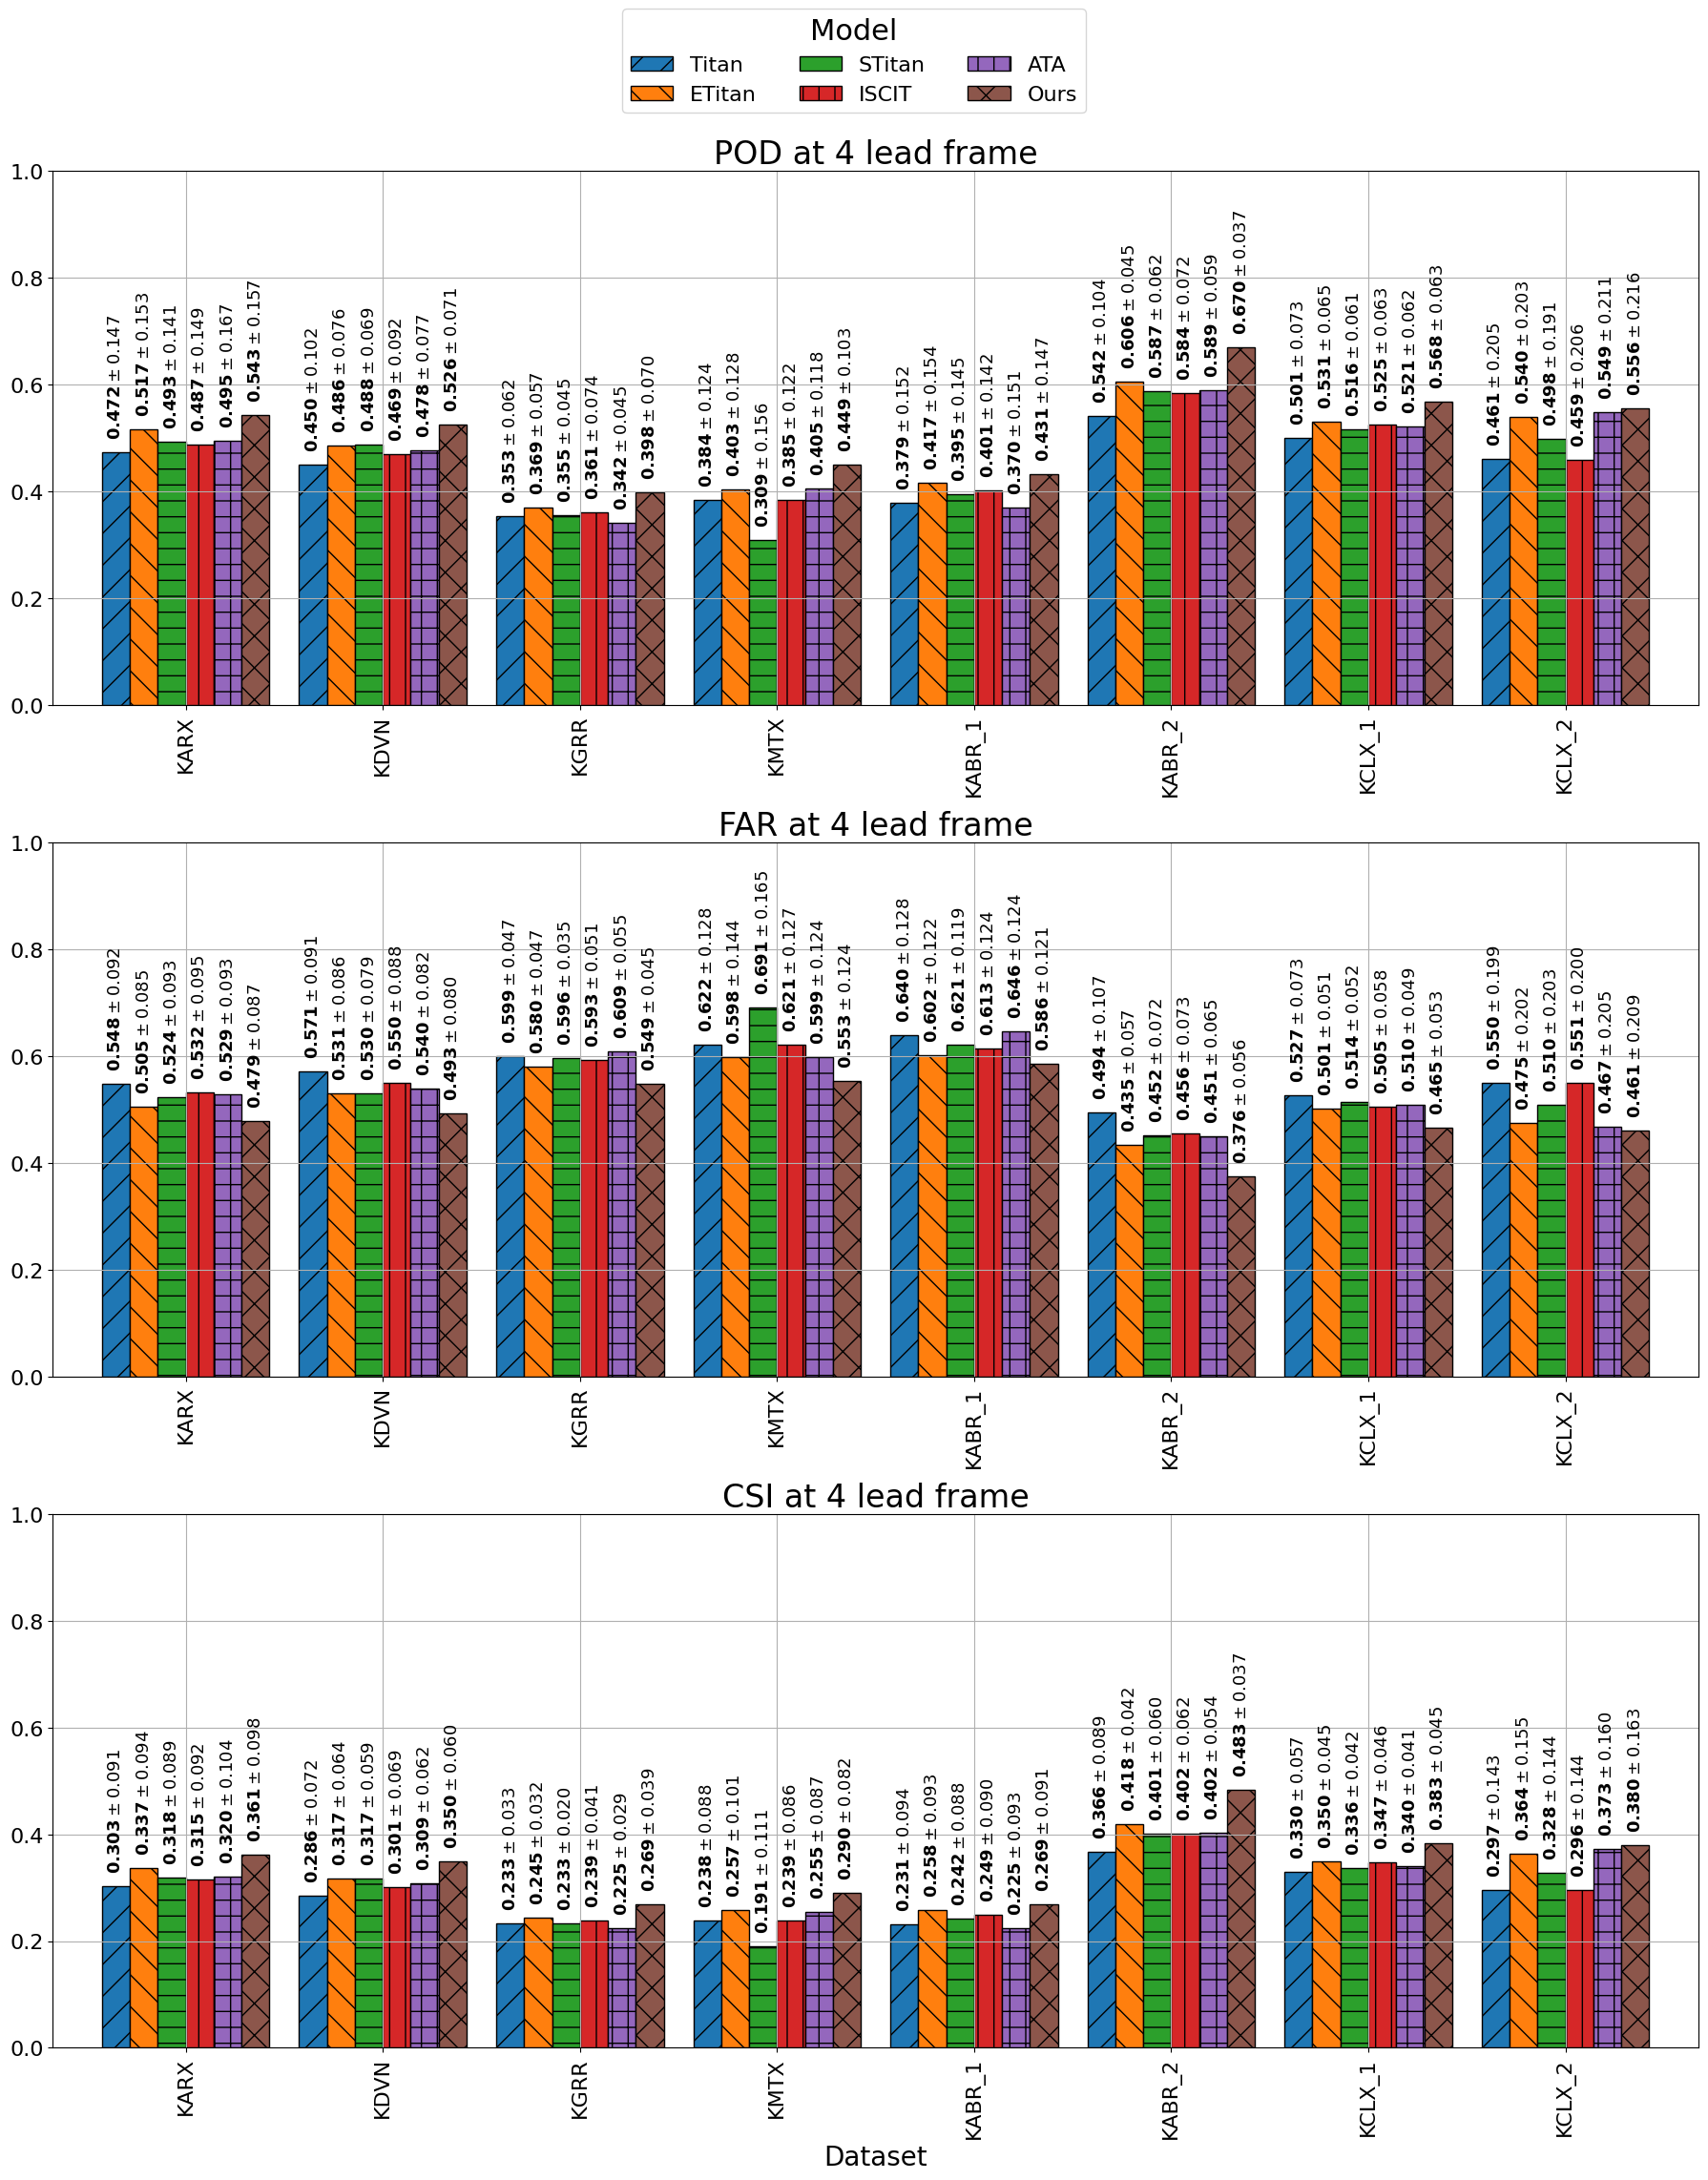

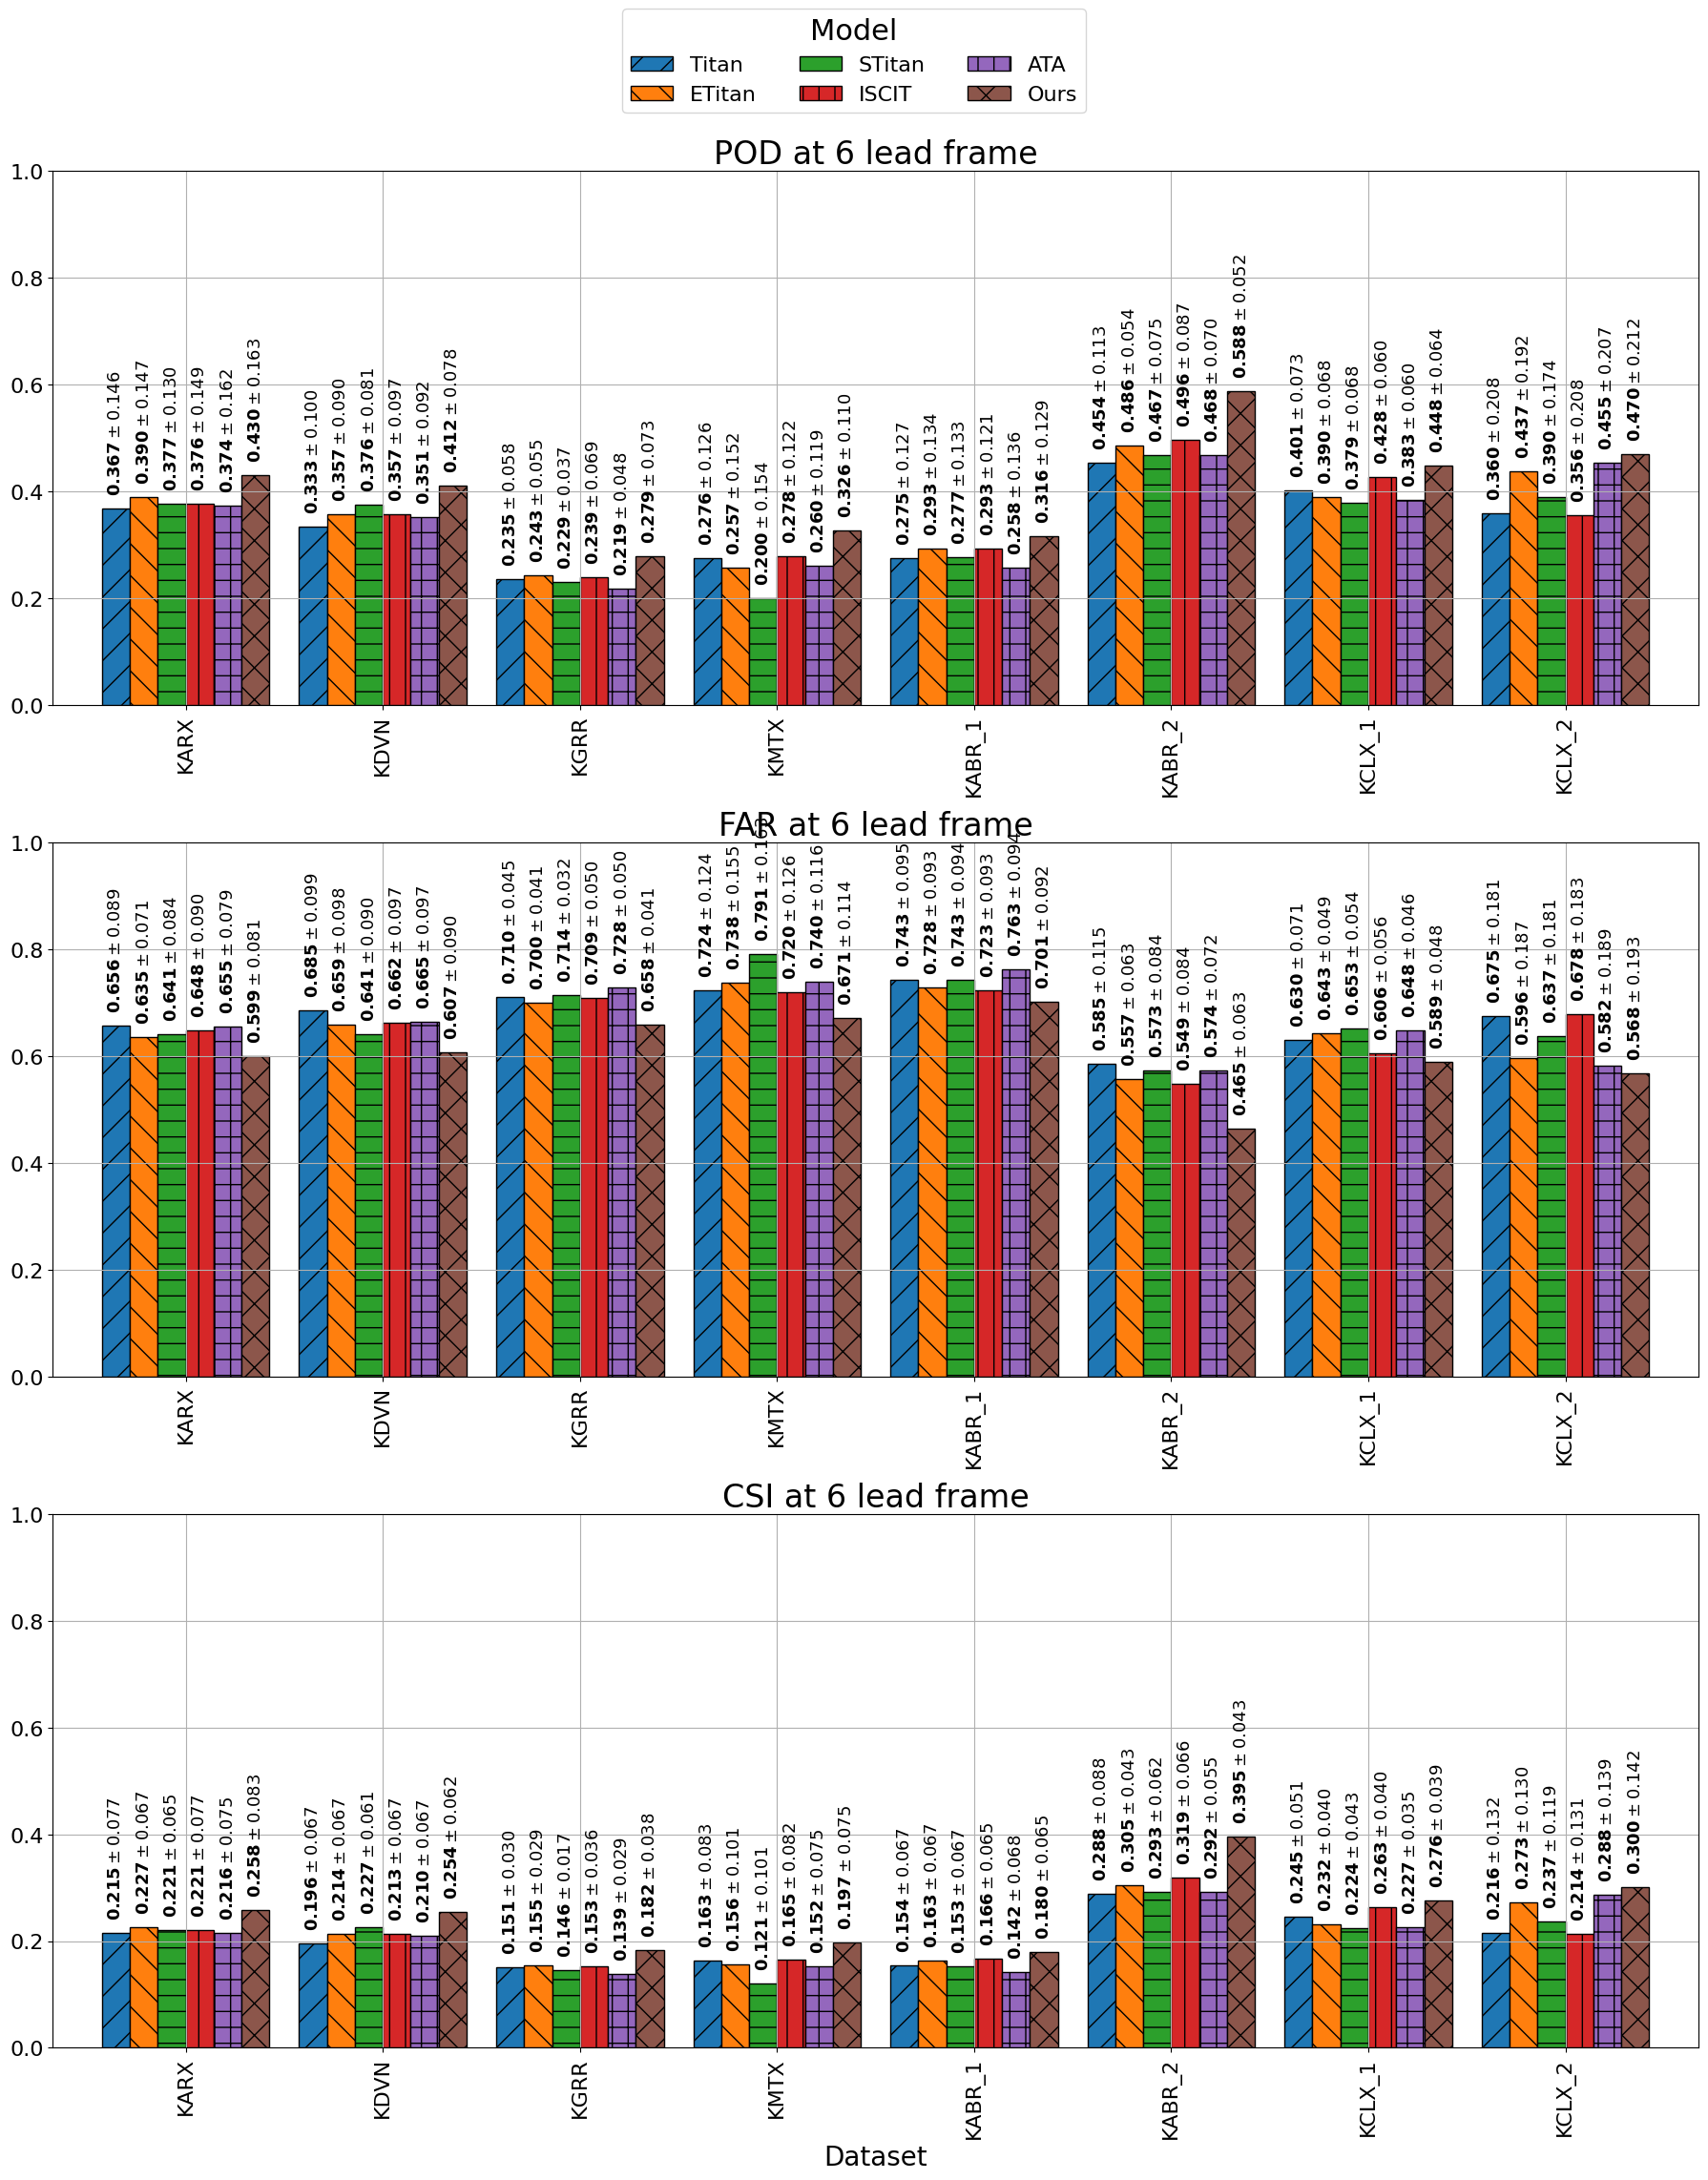

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load the data
DATASETS = ["KARX", "KDVN", "KGRR", "KMTX", "KABR_1", "KABR_2", "KCLX_1", "KCLX_2"]
model_names = ['titan', 'etitan', 'stitan', 'iscit', 'ata', 'ours']
metrics = ['pod', 'far', 'csi']

# Define hatch patterns for each model
hatches = ['/', '\\', '-', '|', '+', 'x', 'o']

def plot_nowcasting_evaluation(forward_time: int):
    # 2. Create a single figure with 3 subplots (3 rows, 1 column)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 24), sharex=False)

    for idx, metric in enumerate(metrics):
        dataframe = pd.DataFrame(columns=['Dataset'] + model_names)
        std_dataframe = pd.DataFrame(columns=['Dataset'] + model_names)
        ax = axes[idx]

        for dataset in DATASETS:
            file_path = f"output/results_with_std/{dataset}_models_evaluation.csv"
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"File not found: {file_path}")

            df = pd.read_csv(file_path).set_index('model_name')
            df = df.reindex(model_names)

            metric_column = f'{metric}_{forward_time}'
            std_column = f'{metric_column}_std'
            if metric_column not in df.columns or std_column not in df.columns:
                raise KeyError(
                    f"Expected columns '{metric_column}' and '{std_column}' not found in {file_path}"
                )

            mean_row = {'Dataset': dataset}
            mean_row.update(df[metric_column].to_dict())
            dataframe.loc[len(dataframe)] = mean_row

            std_row = {'Dataset': dataset}
            std_row.update(df[std_column].to_dict())
            std_dataframe.loc[len(std_dataframe)] = std_row

        dataframe = dataframe.set_index('Dataset')
        std_dataframe = std_dataframe.set_index('Dataset')

        # 3. Plot directly onto the specific subplot
        dataframe.plot(
            kind='bar',
            ax=ax,
            width=0.85,
            grid=True,
            fontsize=16,
            legend=False,
            edgecolor='black'
        )

        # Apply hatch patterns and mean +/- standard-deviation labels
        for i, container in enumerate(ax.containers):
            hatch_pattern = hatches[i % len(hatches)]
            for patch in container:
                patch.set_hatch(hatch_pattern)

            model_name = model_names[i]
            std_values = std_dataframe[model_name].to_numpy()
            labels = [
                f'$\\mathbf{{{mean_value:.3f}}} \\pm {std_value:.3f}$'
                if pd.notna(mean_value) and pd.notna(std_value)
                else ''
                for mean_value, std_value in zip(container.datavalues, std_values)
            ]
            ax.bar_label(container, labels=labels, rotation=90, padding=10, fontsize=13)

        # 4. Formatting for individual subplots
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
        ax.set_title(f'{metric.upper()} at {forward_time+1} lead frame', fontsize=24)
        ax.set_ylim(0, 1.0)  # Set y-axis limit to [0, 1] for all metrics

        if idx == len(metrics) - 1:
            ax.set_xlabel('Dataset', fontsize=20)
        else:
            ax.set_xlabel('')

    # 5. Extract handles and labels from the first subplot to make the shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    # 6. Change the labels to the more descriptive ones
    labels = ['Titan', 'ETitan', 'STitan', 'ISCIT', 'ATA', 'Ours']

    # Make legend with at most four elements per row
    fig.legend(
        handles,
        labels,
        title='Model',
        loc='upper center',
        bbox_to_anchor=(0.5, 0.955),
        ncol=min(3, len(labels)),
        fontsize=16,
        title_fontsize=22
    )

    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
    plt.savefig(
        f"output/tracking/nowcasting_evaluation_{forward_time}.png",
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.2
    )
    plt.show()

plot_nowcasting_evaluation(forward_time=3)
plot_nowcasting_evaluation(forward_time=5)

### B. Visualize Tracking Results

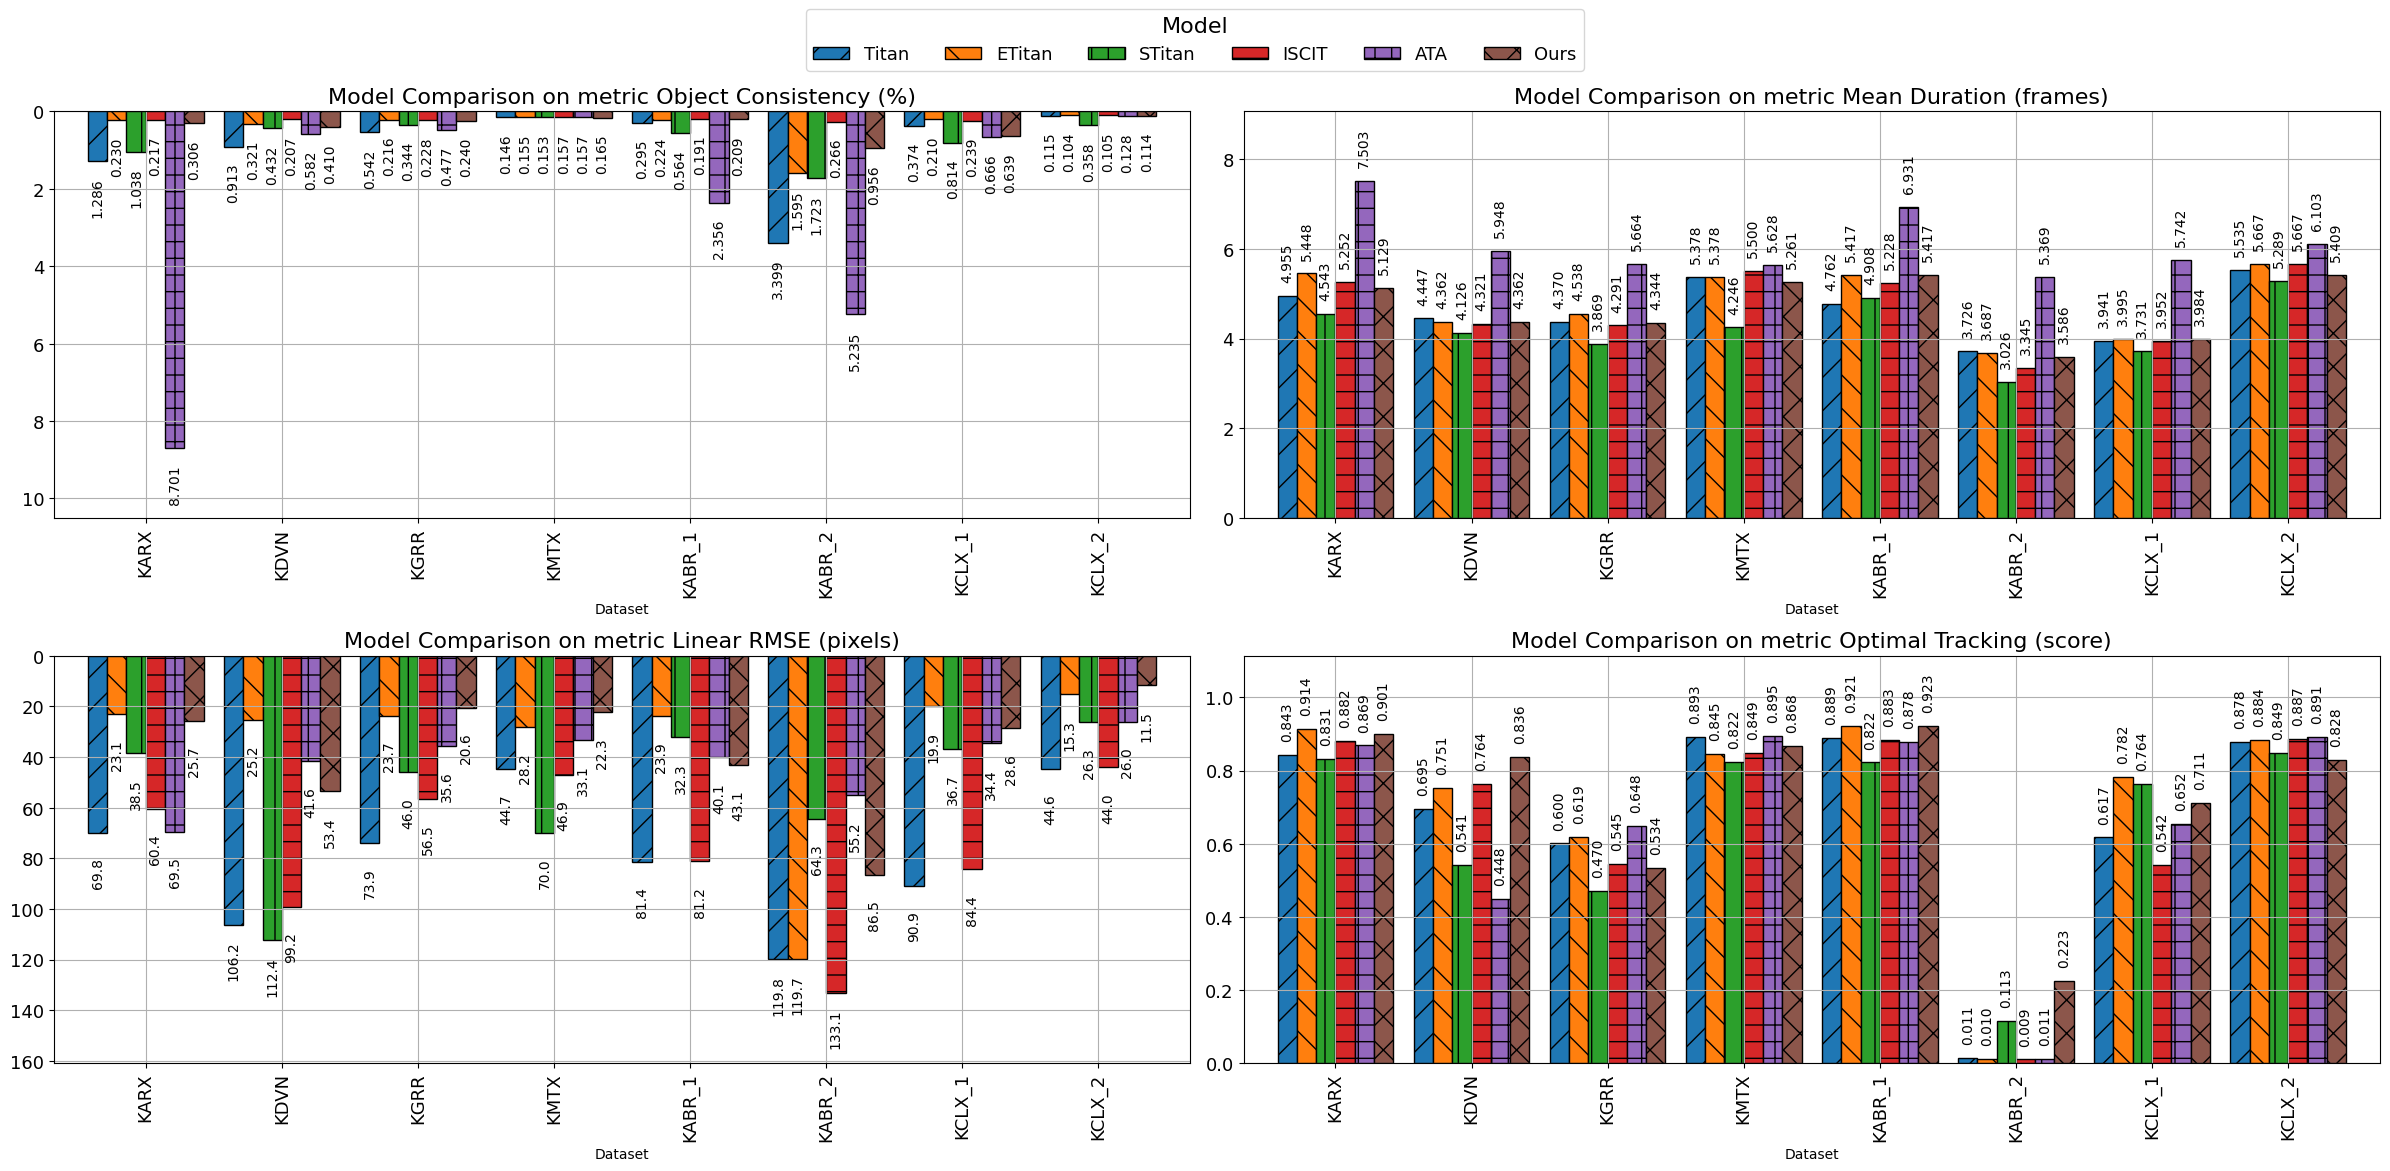

In [33]:
# 1. Load the tracking result
MODEL_NAME = ['titan', 'etitan', 'stitan', 'iscit', 'ata', 'ours']
BASE_DIR = "output/results_with_std"

tracking_metrics = ["Object Consistency", "Mean Duration", "Linear RMSE", "Optimal Tracking"]
tracking_columns = ["object_consistency", "mean_duration", "linear_rmse", "optimal_tracking"]
units = ["(%)", "(frames)", "(pixels)", "(score)"]

dataframe_dict = {}
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(24, 12))
axes = axes.flatten()

for idx in range(4):
    dataframe_dict[tracking_metrics[idx]] = pd.DataFrame(columns=['Dataset'] + MODEL_NAME)

    for dataset in DATASETS:
        file_path = f"{BASE_DIR}/{dataset}_models_evaluation.csv"
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        
        df = pd.read_csv(file_path)
        df.set_index('model_name', inplace=True)
        df = df.loc[MODEL_NAME, :]

        temp_df = df[tracking_columns[idx]]
        row = {'Dataset': dataset}
        for model_name, value in zip(MODEL_NAME, temp_df):
            row[model_name] = value
        dataframe_dict[tracking_metrics[idx]].loc[len(dataframe_dict[tracking_metrics[idx]])] = row

    dataframe_dict[tracking_metrics[idx]].set_index('Dataset', inplace=True)

    ax = dataframe_dict[tracking_metrics[idx]].plot(
        kind='bar',
        ax=axes[idx],
        width=0.85,
        title=f'Metric {tracking_metrics[idx]} {units[idx]}',
        grid=True,
        fontsize=13,
        edgecolor='black',
        legend=False
    )

    hatches = ['/', '\\', '|', '-', '+', 'x']
    for i, container in enumerate(ax.containers):
        hatch_pattern = hatches[i % len(hatches)]
        for patch in container:
            patch.set_hatch(hatch_pattern)

        ax.bar_label(
            container,
            fmt='%.3f' if idx != 2 else '%.1f',
            rotation=90,
            padding=10 if idx % 2 == 1 else -40,
            fontsize=10
        )

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.set_title(f'Model Comparison on metric {tracking_metrics[idx]} {units[idx]}', fontsize=16)
    if idx % 2 == 0:
        ax.invert_yaxis()

handles = [container.patches[0] for container in axes[0].containers]
legend_labels = ['Titan', 'ETitan', 'STitan', 'ISCIT', 'ATA', 'Ours']
fig.legend(
    handles,
    legend_labels,
    title='Model',
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=6,
    fontsize=13,
    title_fontsize=16
)

fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
fig.savefig('output/tracking/tracking_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from src.cores.metrics import tracking_score_normalization

normalized_dataframe_dict = {}
increase_list = [False, True, False, True]  # Define increase_mode for each metric

# Go through 4 tracking metrics and compute the total tracking score for all algorithms
for increase_mode , (key, dataframe) in zip(increase_list, dataframe_dict.items()):
    normalized_dataframe = pd.DataFrame(columns=['Dataset'] + MODEL_NAME)
    for row in dataframe.itertuples():
        dataset = row.Index
        scores = row[1:]  # Exclude the index (dataset name)
        normalized_scores = tracking_score_normalization(scores, increase_mode)
        normalized_dataframe.loc[len(normalized_dataframe)] = (
            [dataset] + list(normalized_scores)
        )
    normalized_dataframe_dict[key] = normalized_dataframe

# Preserve the Dataset column and sum corresponding model scores element-wise
total_tracking_score_df = next(iter(normalized_dataframe_dict.values()))[
    ['Dataset'] + MODEL_NAME
].copy()

total_tracking_score_df[MODEL_NAME] = sum(
    (dataframe[MODEL_NAME] for dataframe in normalized_dataframe_dict.values()),
    start=pd.DataFrame(
        0.0,
        index=total_tracking_score_df.index,
        columns=MODEL_NAME
    )
)

# Average and std by columns:
average_total_tracking_score_df = total_tracking_score_df[MODEL_NAME].mean()
std_total_tracking_score_df = total_tracking_score_df[MODEL_NAME].std()

total_tracking_score_df

,Dataset,titan,etitan,stitan,iscit,ata,ours
0,KARX,1.163673,3.304248,1.573678,2.048651,1.458443,2.977418
1,KDVN,0.884615,2.748027,0.921969,2.073550,2.280829,2.518170
2,KGRR,1.009533,3.148779,1.130171,1.943575,2.919802,2.548221
3,KMTX,3.320971,2.569871,0.672961,2.220639,3.228127,2.363043
4,KABR_1,1.615385,3.274143,1.750487,1.825634,2.275923,2.960500
5,KABR_2,0.852106,1.193610,2.077206,1.136153,2.011137,2.698186
6,KCLX_1,1.144852,3.131065,1.687820,1.154372,2.499984,1.996188
7,KCLX_7,2.057631,3.250905,0.885947,2.409530,3.465872,2.108305


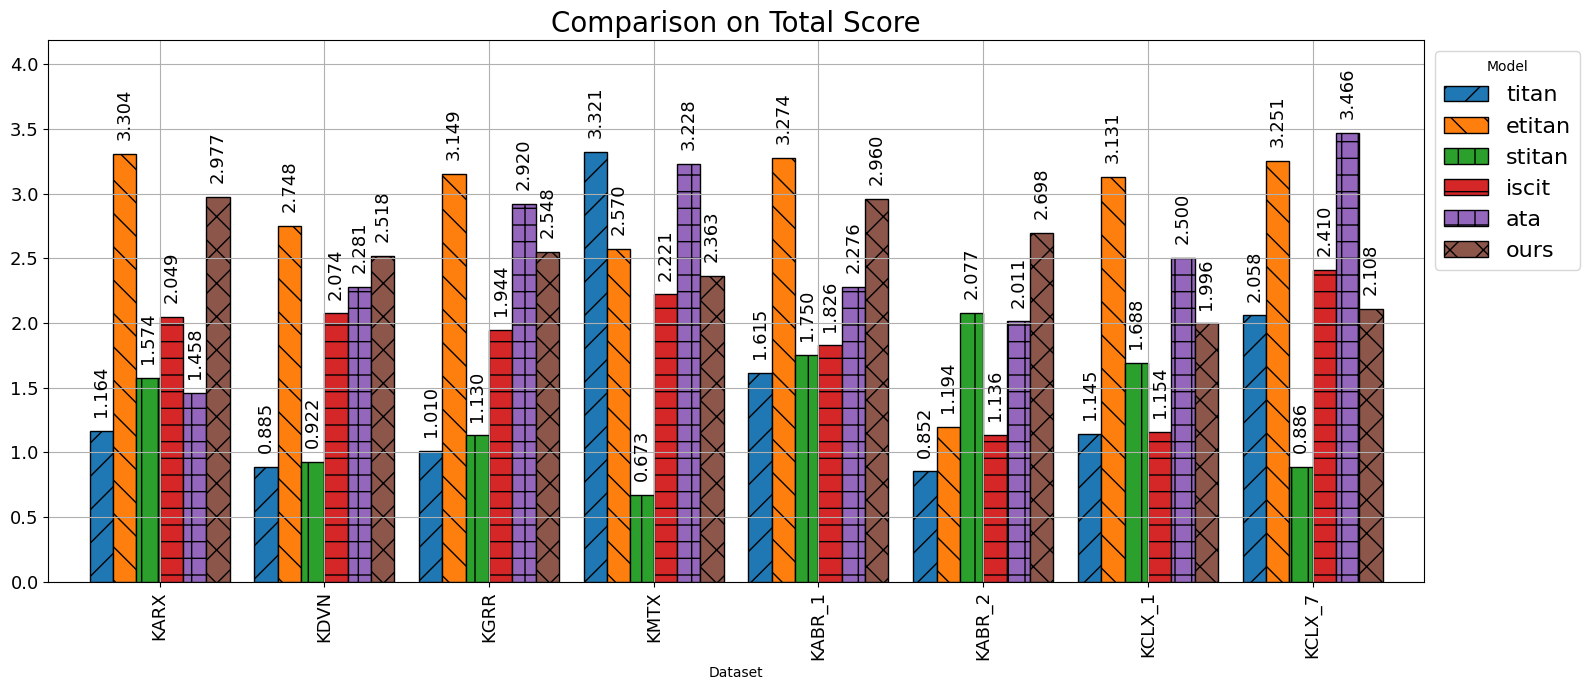

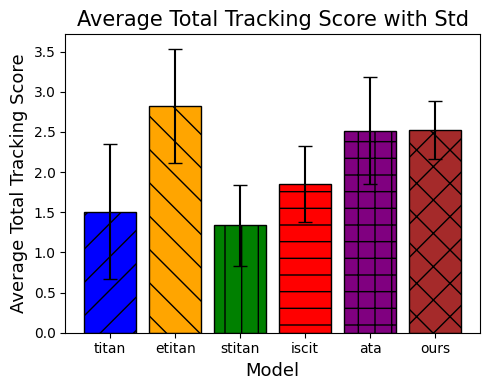

In [ ]:
if 'Dataset' in total_tracking_score_df.columns:
    total_tracking_score_df.set_index('Dataset', inplace=True)

# 1. Plot with the width adjustment
ax = total_tracking_score_df.plot(
    kind='bar', 
    figsize=(16, 7), 
    width=0.85, 
    title=f'Comparison on Total Score', 
    grid=True, 
    fontsize=13,
    edgecolor='black' 
)

# 2. Define a list of hatch patterns for the 6 models
hatches = ['/', '\\', '|', '-', '+', 'x']

# 3. Iterate through containers to apply labels and hatches
for i, container in enumerate(ax.containers):
    # Apply the corresponding hatch pattern to each bar in this group
    hatch_pattern = hatches[i % len(hatches)]
    for patch in container:
        patch.set_hatch(hatch_pattern)
        
    # Apply the bar labels as before
    ax.bar_label(container, fmt='%.3f' if IDX != 2 else '%.1f', rotation=90, padding=10 if IDX % 2 == 1 else -40, fontsize=13)

# 4. Give the vertical labels some breathing room at the top
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', fontsize=16)
plt.title(f'Comparison on Total Score', fontsize=20)
plt.tight_layout()

plt.savefig(f'output/tracking/tracking_total_score_comparison.png')
plt.show()

# Plot the average and std of total tracking score for all models
# with the same colors and hatch patterns as the previous bar plots
plt.figure(figsize=(5, 4))

# Match the same color mapping as the previous plots
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

bars = plt.bar(
    average_total_tracking_score_df.index,
    average_total_tracking_score_df.values,
    yerr=std_total_tracking_score_df.values,
    capsize=5,
    color=colors,
    edgecolor='black',
    linewidth=1.0
)

# Apply matching hatch pattern for each model
for i, bar in enumerate(bars):
    bar.set_hatch(hatches[i % len(hatches)])

plt.title('Average Total Tracking Score with Std', fontsize=15)
plt.xlabel('Model', fontsize=13)
plt.ylabel('Average Total Tracking Score', fontsize=13)
plt.tight_layout()
plt.savefig(f'output/tracking/tracking_total_score_average.png')
plt.show()